# Introduction to Machine Learning for Neuroscience
# Final Project
**05/03/2025** 

**Gilad Shilo ID: 318337136**

**Iakov Odesser ID: 209860288**

## EDA

We begin by loading the EmoSet dataset from JSON and flattening the nested annotations into a pandas DataFrame. 


In [61]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import wordcloud

In [62]:
file_path = 'emoset_challenge_1000_augmented.json'
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data, sep='_')  # flatten nested annotations

print("--- Data Overview ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_image_id           1000 non-null   object 
 7   annotations_emotion            1000 non-null   object 
 8   annotations_brightness         999 non-null    float64
 9   annotations_colorfulness       976 non-null    float64
 10  annotations_facial_expression  112 non-null    object 
 11  annotations_object             513 non-null    object 
 12  annotations_human_action   

It seems that image_name and annotations_image_id are the same. We'll make sure that they are indeeed 100% identical and drop the latter if the assumption holds 

In [63]:
df = df.drop(columns=['annotations_image_id']) if (df['image_name'].str.replace('.jpg', '', regex=False) == df['annotations_image_id']).all() else df
df_work = df.copy() 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_emotion            1000 non-null   object 
 7   annotations_brightness         999 non-null    float64
 8   annotations_colorfulness       976 non-null    float64
 9   annotations_facial_expression  112 non-null    object 
 10  annotations_object             513 non-null    object 
 11  annotations_human_action       114 non-null    object 
 12  annotations_scene              212 non-null    ob

Indeed, annotations_image_id is redundant 

Let's take a look at what the table looks like now. We roll out 10 random rows for preview:

In [64]:
from IPython.display import display

display(df.drop(columns=[col for col in df.columns if 'embedding' in col])
          .sample(5, random_state=42)
          .reset_index(drop=True)
          .style.set_properties(**{'text-align': 'left'})
          .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,image_name,description,viewer_feelings,annotations_emotion,annotations_brightness,annotations_colorfulness,annotations_facial_expression,annotations_object,annotations_human_action,annotations_scene
0,amusement_16760.jpg,"A circular ornament hangs on a Christmas tree, featuring a painted depiction of Santa Claus with a red hat, the text ""Merry Christmas! 2012,"" and the name ""Paxton"" at the bottom, surrounded by colorful lights and evergreen branches.","A viewer looking at this ornament might feel a warm sense of nostalgia, recalling joyful holiday memories and the significance of handmade gifts. The cheerful design could evoke feelings of love and family, particularly during the festive season.",amusement,0.400000,0.600000,nan,['Tree'],nan,nan
1,amusement_12611.jpg,"The image shows a colorful Ferris wheel with yellow, red, and blue passenger cars against a bright blue sky, surrounded by festive banners and flags.","A viewer might feel a sense of nostalgia and excitement when looking at the colorful ferris wheel, evoking memories of fun times at fairs or amusement parks. The vibrant colors and cheerful scene can also inspire a feeling of joy and anticipation for the carefree moments that lie ahead.",amusement,0.600000,0.500000,nan,['Flag'],nan,nan
2,excitement_06571.jpg,"A musician stands on stage, wearing a dark suit and playing a white electric guitar, with a microphone and amplifiers visible in the background under dim lighting.","A viewer might feel energized and captivated by the dynamic performance captured in the image, sensing the passion and intensity emanating from the musician. The focused expression could evoke a sense of admiration for the artist's dedication to their craft.",excitement,0.300000,0.600000,nan,['Musical instrument'],playing bass guitar,stage
3,contentment_14022.jpg,"A woman and a child are lying on beach towels beneath a gray blanket, smiling at the camera, with lounge chairs and a stone wall in the background.","The viewer might feel warmth and joy from the affectionate moment captured between the two individuals, reflecting a sense of intimacy and happiness. The smiles suggest a shared connection, evoking feelings of love and contentment.",contentment,0.500000,0.700000,nan,nan,nan,nan
4,fear_00313.jpg,"A close-up image captures the vibrant green and yellow feathers of a parrot, whose wide open beak reveals its textured interior against a dark background.","A viewer might feel a sense of joy and amusement upon seeing the vibrant colors and lively expression of the bird, evoking a playful and cheerful atmosphere. The close-up perspective may also spark curiosity about the bird's personality and actions.",fear,0.300000,0.600000,nan,"['Parrot', 'Animal']",nan,nan


We now proceed to explore the descriptives: 

In [65]:
print("\n--- Emotion Distribution ---")
emotion_counts = df['annotations_emotion'].value_counts()
print(emotion_counts)

print("\n--- Summary Statistics for Visual Features ---")
print(df[['annotations_brightness', 'annotations_colorfulness']].describe())



--- Emotion Distribution ---
annotations_emotion
anger          125
excitement     125
disgust        125
amusement      125
awe            125
contentment    125
sadness        125
fear           125
Name: count, dtype: int64

--- Summary Statistics for Visual Features ---
       annotations_brightness  annotations_colorfulness
count              999.000000                976.000000
mean                 0.483884                  0.493545
std                  0.151183                  0.195302
min                  0.000000                  0.000000
25%                  0.400000                  0.400000
50%                  0.500000                  0.500000
75%                  0.600000                  0.600000
max                  0.900000                  1.000000


Evidently, we have a uniform distribution. The columns of interest almost lack NaN values, and we'll handle them later on. We now proceed to plotting: 

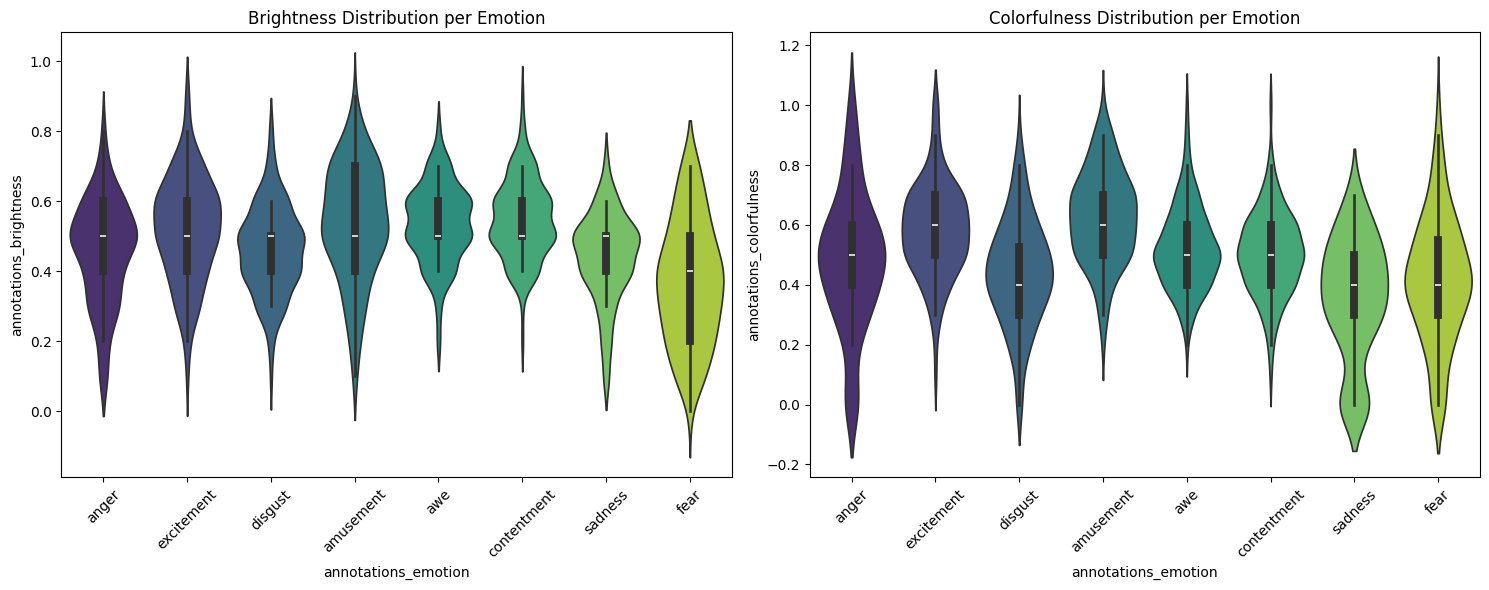

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # brightness & colorfulness per emotion
sns.violinplot(ax=axes[0], data=df, x='annotations_emotion', y='annotations_brightness', palette='viridis', hue='annotations_emotion', legend=False)

axes[0].set_title('Brightness Distribution per Emotion')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(ax=axes[1], data=df, x='annotations_emotion', y='annotations_colorfulness', palette='viridis', hue='annotations_emotion', legend=False)
axes[1].set_title('Colorfulness Distribution per Emotion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From the violin plots, we can observe:

*Brightness:* Fear is associated with darker images, while amusement and excitement tend toward brighter imagery, suggesting a relationship between image brightness and emotional valence.

*Colorfulness:* Sadness and fear exhibit notably lower colorfulness compared to other emotions, while excitement and amusement show higher saturation, indicating that positive high-arousal emotions correlate with more vibrant imagery.

We also examine the distribution of description lengths to assess consistency in the GPT-generated captions.

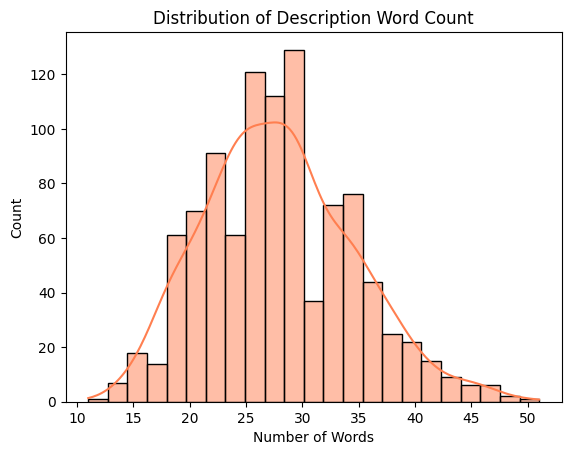

In [67]:
df_work['description_word_count'] = df_work['description'].str.split().str.len()

sns.histplot(df_work['description_word_count'], kde=True, color='coral')
plt.title('Distribution of Description Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

### Embedding Alignment Analysis

We compute the cosine similarity between each image's GPT-generated description embedding and its viewer feelings embedding - both from `text-embedding-3-small`, making them directly comparable. High similarity would suggest that the objective visual description and the subjective emotional response it evokes are closely aligned.

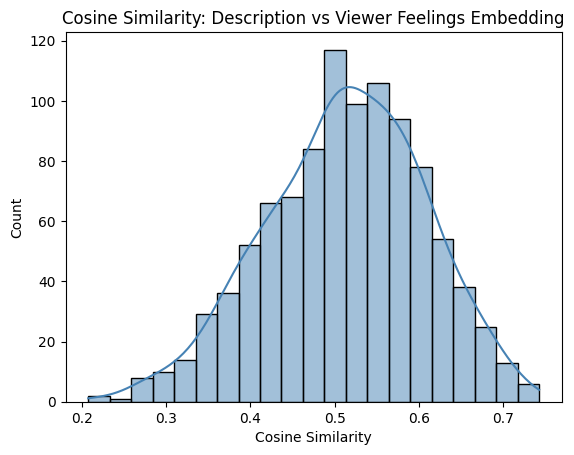

Mean similarity: 0.513
Std: 0.095


In [68]:
from sklearn.metrics.pairwise import cosine_similarity

desc_embeddings = np.array(df['description_embedding'].tolist())
feelings_embeddings = np.array(df['viewer_feelings_embedding'].tolist())

df_work['desc_feelings_cosine_sim'] = [cosine_similarity([d], [f])[0][0] 
                                        for d, f in zip(desc_embeddings, feelings_embeddings)]

sns.histplot(df_work['desc_feelings_cosine_sim'], kde=True, color='steelblue')
plt.title('Cosine Similarity: Description vs Viewer Feelings Embedding')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

print(f"Mean similarity: {df_work['desc_feelings_cosine_sim'].mean():.3f}")
print(f"Std: {df_work['desc_feelings_cosine_sim'].std():.3f}")

The mean cosine similarity of 0.51 between description and viewer feelings embeddings suggests moderate alignment - the objective visual content and the subjective emotional response it evokes share common semantic space, but are clearly not identical, which is expected given the gap between *what is seen* and *how it feels*.

### Viewer Feelings Word Cloud per Emotion

We visualize the most frequent words in the GPT-generated viewer feelings descriptions for each emotion category. This serves as a qualitative sanity check - if the word clouds are semantically coherent with their emotion label, it validates the quality of the generated text. Words that are very frequent across all emotions due to their natural being part of a description 

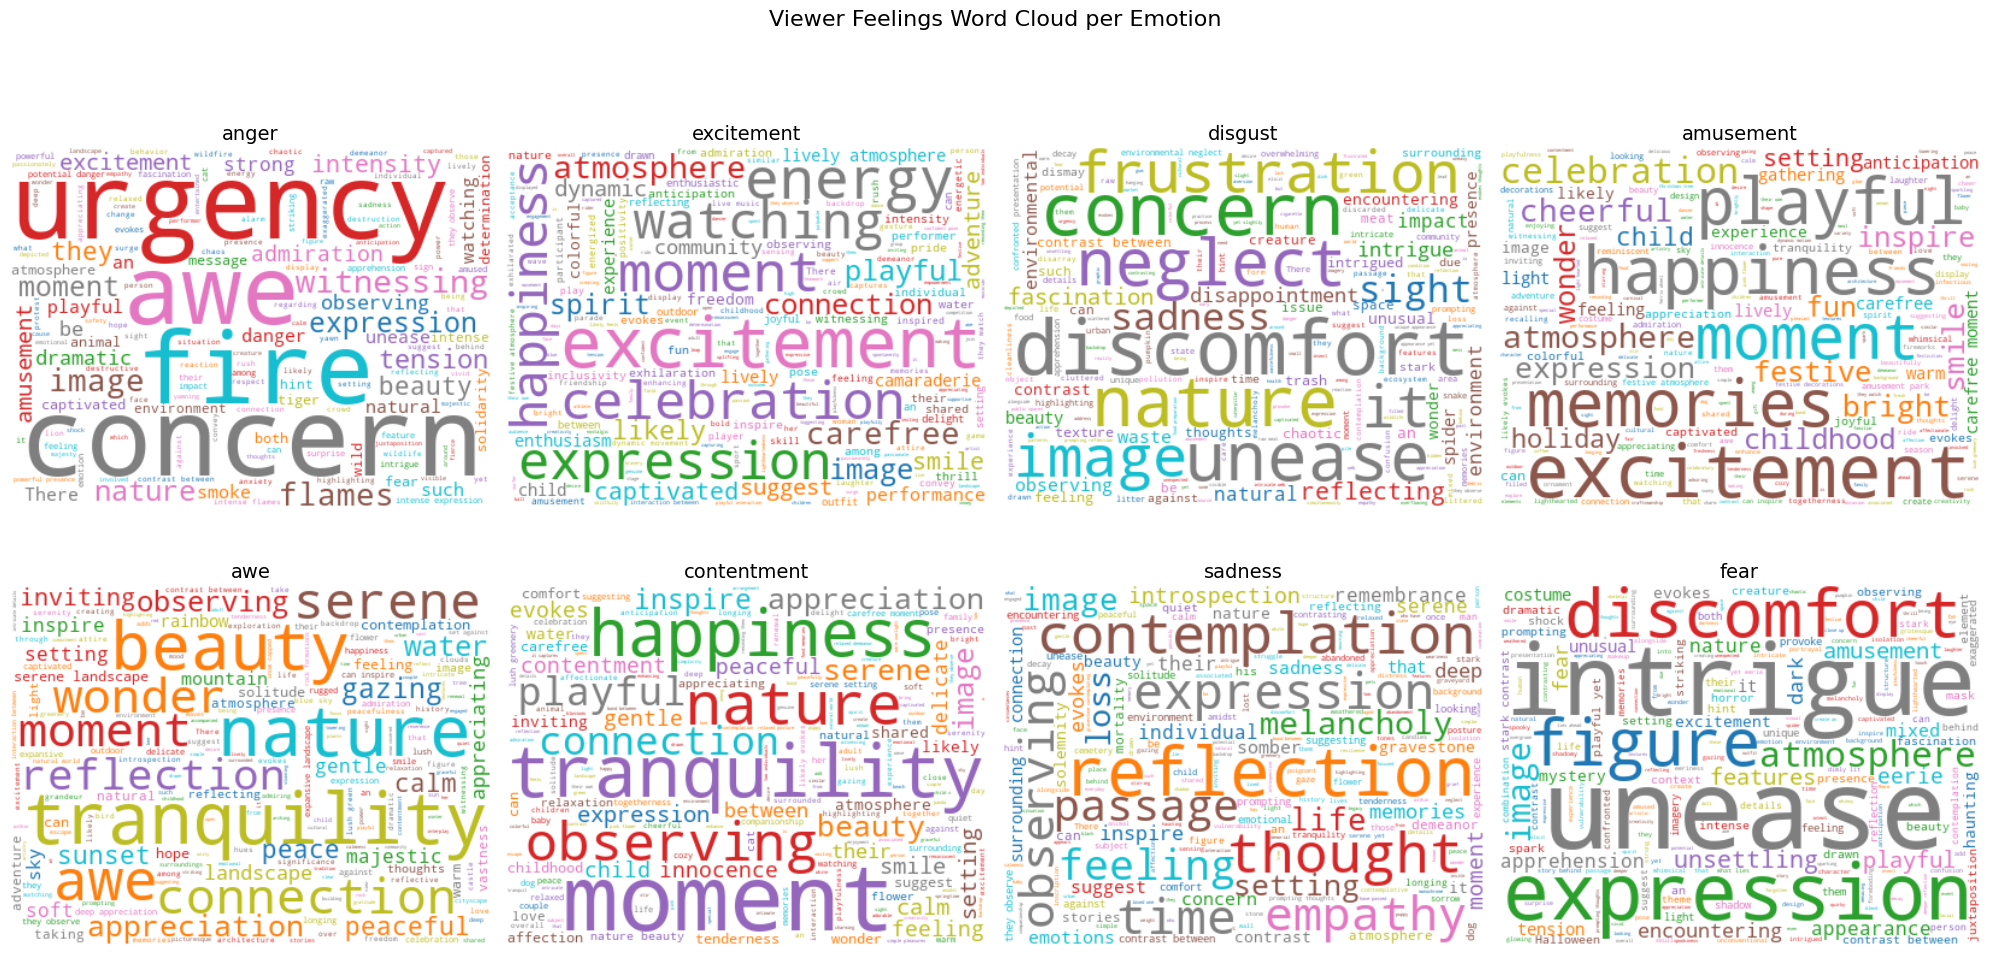

In [69]:
from wordcloud import WordCloud
from collections import Counter

# build global stopword list from words dominant across all emotions
all_text = ' '.join(df['viewer_feelings'].dropna().tolist())
global_freq = Counter(all_text.lower().split())
global_stopwords = {word for word, count in global_freq.items() if count > 140}
                    

emotions = df['annotations_emotion'].unique()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, emotion in zip(axes.flatten(), emotions):
    text = ' '.join(df[df['annotations_emotion'] == emotion]['viewer_feelings'].dropna().tolist())
    wc = WordCloud(width=400, height=300, background_color='white', colormap='tab10',
                   stopwords=global_stopwords).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(emotion, fontsize=14)
    ax.axis('off')

plt.suptitle('Viewer Feelings Word Cloud per Emotion', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The word clouds, after filtering globally dominant GPT phrasing (threshold: >140 occurrences across the dataset), now surface clearly emotion-specific vocabulary - *anger* foregrounds "urgency", "fire" and "concern"; *fear* highlights "unease", "intrigue" and "discomfort"; *awe* centers on "tranquility", "serene" and "wonder"; and *contentment* surfaces "tranquility", "happiness" and "connection" - validating that the GPT-generated viewer feelings are semantically coherent with their emotion labels.

### Description Length per Emotion

We examine whether certain emotions are associated with longer or shorter GPT-generated descriptions, which may hint at the visual complexity of images evoking different emotional responses.

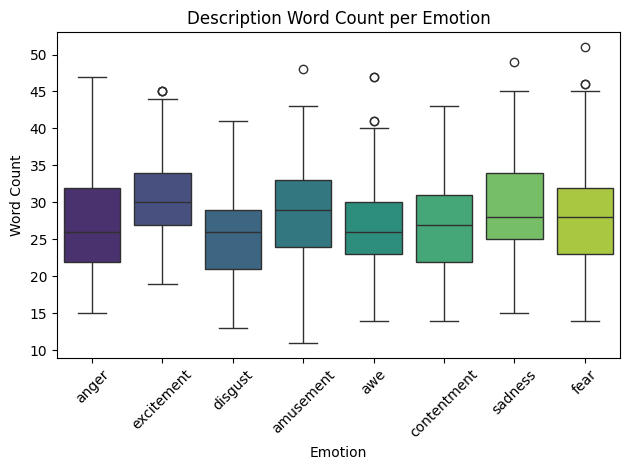

annotations_emotion
excitement     30.416
sadness        29.152
amusement      28.624
fear           28.152
anger          27.512
contentment    27.072
awe            26.728
disgust        25.608
Name: description_word_count, dtype: float64


In [70]:
sns.boxplot(data=df_work, x='annotations_emotion', y='description_word_count', 
            palette='viridis', hue='annotations_emotion', legend=False)
plt.title('Description Word Count per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_work.groupby('annotations_emotion')['description_word_count'].mean().sort_values(ascending=False))

Description length is largely consistent across emotions (median ~26–30 words), suggesting GPT generates captions of similar length regardless of emotional content. Excitement and sadness trend slightly longer, possibly reflecting more complex or narrative-rich scenes, while disgust and awe tend toward shorter descriptions - but the differences are modest and unlikely to be a meaningful signal for modeling.

### Missing Value Analysis

We examine whether missing values in the visual features are randomly distributed across the dataset or systematically concentrated in specific emotion categories - the latter would suggest the missingness is meaningful rather than noise.

--- Missing Values per Column ---
image_name                         0
description                        0
embedding                          0
viewer_feelings                    0
description_embedding              0
viewer_feelings_embedding          0
annotations_emotion                0
annotations_brightness             1
annotations_colorfulness          24
annotations_facial_expression    888
annotations_object               487
annotations_human_action         886
annotations_scene                788
dtype: int64

--- Missing Values per Emotion ---
                     annotations_brightness  annotations_colorfulness  \
annotations_emotion                                                     
amusement                                 0                         1   
anger                                     0                        10   
awe                                       0                         2   
contentment                               0                         0  

C:\Users\odis\AppData\Local\Temp\ipykernel_67992\385306808.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\odis\AppData\Local\Temp\ipykernel_67992\385306808.py:11: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



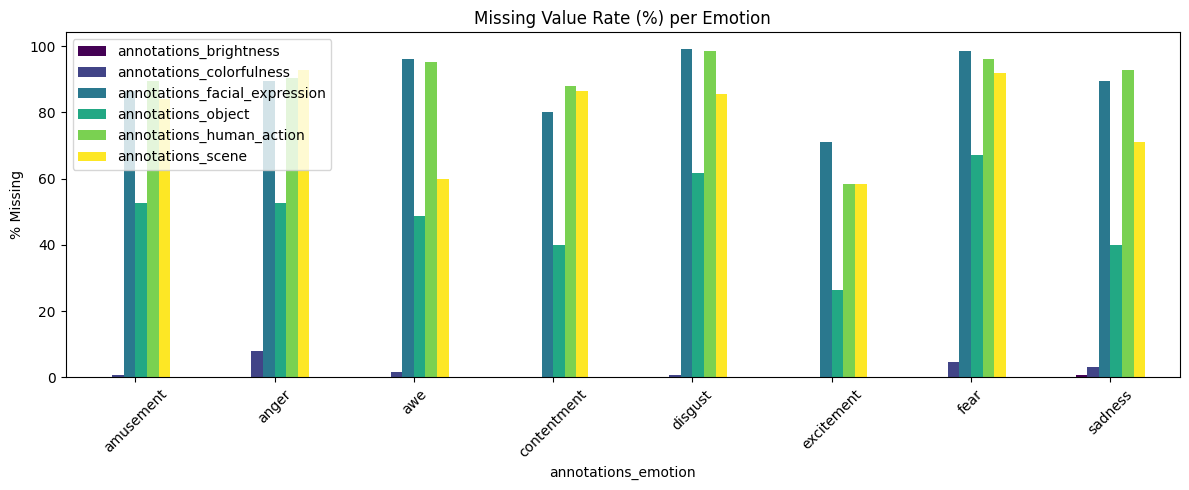

In [71]:
# missing values overview
print("--- Missing Values per Column ---")
print(df.isnull().sum())

# missing values per emotion category
print("\n--- Missing Values per Emotion ---")
missing_by_emotion = df.groupby('annotations_emotion').apply(lambda x: x.isnull().sum())
print(missing_by_emotion[[col for col in df.columns if df[col].isnull().any()]])

# visualize missingness per emotion
missing_rates = df.groupby('annotations_emotion').apply(
    lambda x: x.isnull().mean() * 100
)[[col for col in df.columns if df[col].isnull().any()]]

missing_rates.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Missing Value Rate (%) per Emotion')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see from the chart, brightness and colorfulness are nearly complete across all emotions and can be used as-is. The remaining features - facial expression, object, human action, and scene - are massively sparse (40–100% missing), which is expected given that not every image contains a face, object, or identifiable scene. Notably, missingness is not uniformly random: excitement images have substantially lower missing rates, suggesting they more frequently depict people in action, while awe and disgust show near-complete absence of facial expressions, implying these emotions are more scene-driven. We can also see that the features annotations_human_action, annotations_scene and annotations_facial_expression are largely missing.

Let's roll out a small non-representing sample to try and get a feel for the relationship between the annotations and description: 

In [72]:
import random
random.seed(42)

sparse_features = ['annotations_facial_expression', 'annotations_object', 
                   'annotations_human_action', 'annotations_scene', ]

for feature in sparse_features:
    print(f"\n{'='*60}")
    print(f"FEATURE: {feature}")
    print(f"{'='*60}")
    
    missing_samples = df[df[feature].isna()]['description'].dropna().tolist()
    present_samples = df[df[feature].notna()][['description', feature]].dropna().values.tolist()
    
    if missing_samples:
        sample = random.choice(missing_samples)
        print(f"\n[MISSING] {feature} = NaN")
        print(f"Description: {sample}")
    
    if present_samples:
        desc, val = random.choice(present_samples)
        print(f"\n[PRESENT] {feature} = '{val}'")
        print(f"Description: {desc}")


FEATURE: annotations_facial_expression

[MISSING] annotations_facial_expression = NaN
Description: A band performs on stage, featuring a guitarist with long hair playing a light green guitar, a vocalist in a blue shirt holding a red guitar, and a drummer in the background, with colorful stage lighting enhancing the scene.

[PRESENT] annotations_facial_expression = 'happy'
Description: A woman lies in a bed surrounded by cushions, holding an infant in her arm while a young boy in pajamas hugs her from behind, and a soft light illuminates the cozy room.

FEATURE: annotations_object

[MISSING] annotations_object = NaN
Description: A person in a gray jacket and black leggings stands on a grassy hillside at sunset, next to a wooden information sign, with rolling hills and distant mountains in the background.

[PRESENT] annotations_object = '['Plant']'
Description: A wooden structure is engulfed in large flames billowing smoke into the air, surrounded by a grassy field and a wooden fence.



as we can see, the attributes don't neccessarily reflect the description of the picture and seem quite unreliable (e. g. in the last exampe the scene should be sky rather than NaN etc.)

### Feature Correlation Analysis

We're going to have to perform dimentionality reduction on the embeddings to try and see if we can find any meaningful correlations. However, even now we can see that the Pearson Correlation between brightness and colorfulness is 0.24 which indicates that they're largely independant - good news.

In [73]:
print(f"Pearson correlation between brightness and colorfulness: {df['annotations_brightness'].corr(df['annotations_colorfulness']):.2f}")

Pearson correlation between brightness and colorfulness: 0.24


#### Dimensionality Reduction: PCA

To visualize the structure of the high-dimensional CLIP image embeddings (512-d), we apply Principal Component Analysis (PCA). We first project into 3 components for visualization, then examine the cumulative variance curve to determine how many components are needed to capture 80%+ of the variance - directly informing whether linear reduction is a viable preprocessing step for modeling.

In [74]:
from sklearn.decomposition import PCA
import plotly.express as px

image_embeddings = np.array(df['embedding'].tolist())

pca = PCA(n_components=3)
pca_result = pca.fit_transform(image_embeddings)

df_pca = df.copy()
df_pca['pca_1'], df_pca['pca_2'], df_pca['pca_3'] = pca_result[:, 0], pca_result[:, 1], pca_result[:, 2]

print(f"Variance explained by 3 PCs: {sum(pca.explained_variance_ratio_):.3f}")

fig = px.scatter_3d(df_pca, x='pca_1', y='pca_2', z='pca_3',
                    color='annotations_emotion', hover_name='image_name',
                    title='Interactive 3D PCA of CLIP Image Embeddings', opacity=0.7)
fig.update_traces(marker=dict(size=4))
fig.show()

Variance explained by 3 PCs: 0.139


And let's see how much PCs are needed to explain 80-90 percent of variance

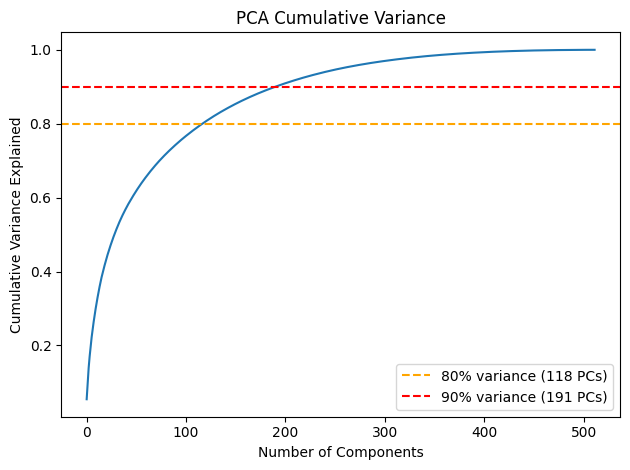

In [75]:
pca_full = PCA().fit(image_embeddings)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_80 = np.argmax(cumvar >= 0.80) + 1
n_90 = np.argmax(cumvar >= 0.90) + 1

plt.plot(cumvar)
plt.axhline(0.80, color='orange', linestyle='--', label=f'80% variance ({n_80} PCs)')
plt.axhline(0.90, color='red', linestyle='--', label=f'90% variance ({n_90} PCs)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.title('PCA Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.show()

The 3D PCA scatter reveals substantial overlap between emotion classes, with no visually separable clusters - confirming that the first 3 components (explaining only 13.9% of variance) are insufficient to linearly separate emotions in CLIP embedding space. The cumulative variance curve reinforces this: *118 PCs are needed to explain 80% of variance, and 191 for 90%*, out of 512 total dimensions. This indicates the CLIP embeddings encode information across a very broad, distributed subspace rather than a few dominant axes - linear dimensionality reduction is therefore not a viable preprocessing step, and models operating on the *full 512-d embeddings* are strongly preferred.

#### Emotion Centroid Similarity in CLIP Embedding Space

To understand which emotions are visually confusable, we compute the mean CLIP embedding (centroid) for each emotion class and plot the pairwise cosine similarity as an 8×8 heatmap. Emotion pairs with high similarity share visual characteristics in embedding space - directly predicting where a classifier is likely to struggle.

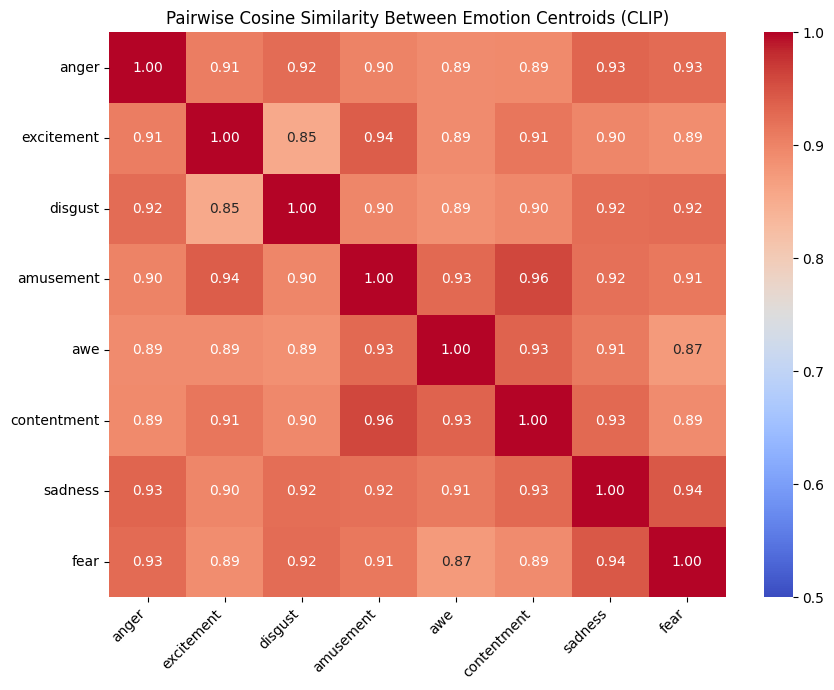

In [76]:
from sklearn.metrics.pairwise import cosine_similarity

emotions = df['annotations_emotion'].unique()
centroids = np.array([image_embeddings[(df['annotations_emotion'] == e).values].mean(axis=0) for e in emotions])

sim_matrix = cosine_similarity(centroids)

plt.figure(figsize=(9, 7))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=emotions, yticklabels=emotions,
            cmap='coolwarm', vmin=0.5, vmax=1.0)
plt.title('Pairwise Cosine Similarity Between Emotion Centroids (CLIP)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

All emotion centroids cluster tightly in CLIP embedding space (similarity range: 0.85–0.96), confirming that emotions are not visually separable at the centroid level - with amusement–contentment (0.96) and sadness–fear (0.94) being the most confusable pairs, and excitement–disgust (0.85) the most distinct - consistent with the PCA findings and indicating the classification challenges.

#### Emotion Centroid Similarity in Text Embedding Space

We repeat the same centroid analysis on the GPT-generated text embeddings (`text-embedding-3-small`) for both the image descriptions and viewer feelings. Comparing these heatmaps to the CLIP one reveals whether the same emotion pairs that are visually confusable are also semantically confusable - if so, it suggests the confusion is inherent to the emotions themselves rather than a limitation of the visual modality alone.

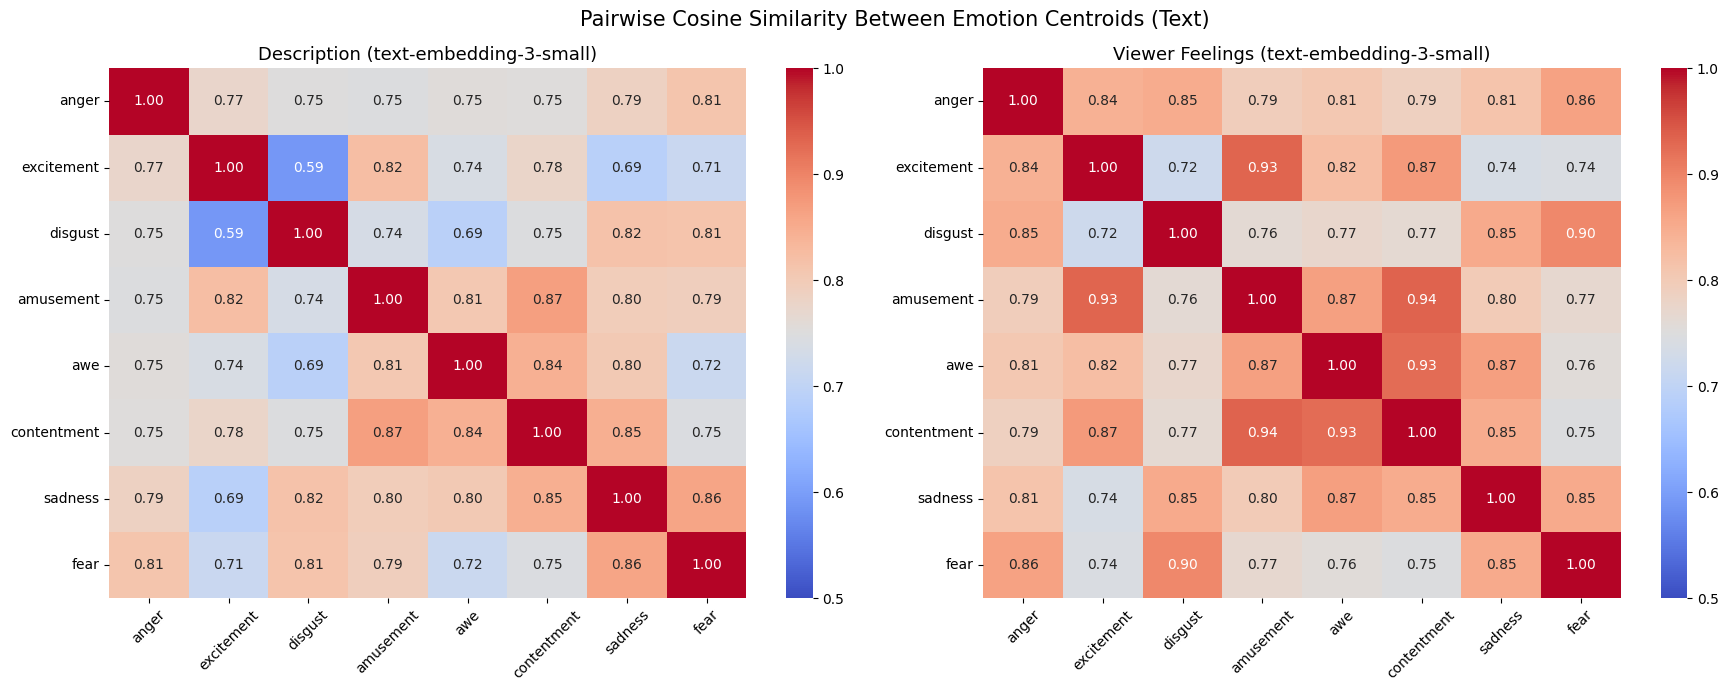

In [77]:
text_modalities = {
    'Description (text-embedding-3-small)': np.array(df['description_embedding'].tolist()),
    'Viewer Feelings (text-embedding-3-small)': np.array(df['viewer_feelings_embedding'].tolist())
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (title, embeddings) in zip(axes, text_modalities.items()):
    centroids = np.array([embeddings[(df['annotations_emotion'] == e).values].mean(axis=0) for e in emotions])
    sim_matrix = cosine_similarity(centroids)
    sns.heatmap(sim_matrix, annot=True, fmt='.2f', xticklabels=emotions, yticklabels=emotions,
                cmap='coolwarm', vmin=0.5, vmax=1.0, ax=ax)
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Pairwise Cosine Similarity Between Emotion Centroids (Text)', fontsize=15)
plt.tight_layout()
plt.show()

Compared to the CLIP heatmap, text embeddings show much greater separation between emotions (range: 0.59–0.94 vs 0.85–0.96) - suggesting that language captures emotional distinctions more effectively than visual features alone. Notably, excitement–disgust are the most semantically distinct pair (0.59), while amusement–contentment (0.94) and awe–contentment (0.93) remain persistently confusable across both modalities, suggesting their overlap is inherent to the emotions themselves rather than a limitation of any single representation.

## Part 1: Predicting Emotions

We train an interpretable model to predict emotion from tabular features: image metadata (brightness, colorfulness), and TfIdf representations of the GPT-generated description and viewer feelings text.

We begin by preparing a clean modeling dataframe from the original data, as well as a quick recap of the important stuff: shape, missing values, emotion distribution


In [86]:
# start from a clean slate — drop image_name, keep only non-embedding columns + target
part1_df = df.drop(columns=[col for col in df.columns if 'embedding' in col])
part1_df = part1_df.drop(columns=['image_name'])

print(f"Shape: {part1_df.shape}")
print(f"\nColumns:\n{part1_df.columns.tolist()}")
print(f"\nMissing values:\n{part1_df.isnull().sum()}")
print(f"\nTarget distribution:\n{part1_df['annotations_emotion'].value_counts()}")

Shape: (1000, 9)

Columns:
['description', 'viewer_feelings', 'annotations_emotion', 'annotations_brightness', 'annotations_colorfulness', 'annotations_facial_expression', 'annotations_object', 'annotations_human_action', 'annotations_scene']

Missing values:
description                        0
viewer_feelings                    0
annotations_emotion                0
annotations_brightness             1
annotations_colorfulness          24
annotations_facial_expression    888
annotations_object               487
annotations_human_action         886
annotations_scene                788
dtype: int64

Target distribution:
annotations_emotion
anger          125
excitement     125
disgust        125
amusement      125
awe            125
contentment    125
sadness        125
fear           125
Name: count, dtype: int64


### Missing Values

We'll tackle brightness and colorfulness after the train-test split to avoid leakage. As we have seen from the violins, they're somewhat skewed so we'll use medians to impute the 25 missing values. 

Regarding the single-word annotations (facial expression, human action, object, etc):
We saw in the EDA that they are unreliable and the relevan information is already contained in a more concrete way in the verbal description. So the most prudent way to go about them is to drop the columns altogether instead of trying and filling them with the "unknown" label that would just add noise:

In [87]:
# drop sparse categorical features — established as unreliable in EDA (40–100% missing, annotations don't consistently reflect image content)
sparse_cols = ['annotations_facial_expression', 'annotations_object', 
               'annotations_human_action', 'annotations_scene']
part1_df = part1_df.drop(columns=sparse_cols)

print(f"Shape: {part1_df.shape}")
print(f"Remaining columns: {part1_df.columns.tolist()}")
print(f"\nMissing values:\n{part1_df.isnull().sum()}")

Shape: (1000, 5)
Remaining columns: ['description', 'viewer_feelings', 'annotations_emotion', 'annotations_brightness', 'annotations_colorfulness']

Missing values:
description                  0
viewer_feelings              0
annotations_emotion          0
annotations_brightness       1
annotations_colorfulness    24
dtype: int64


Our next step is: 


### Train Test Split : Stratify!
Since the EDA confirmed a perfectly uniform class distribution (~125 samples per emotion), we stratify the split to preserve that balance across train and test sets — ensuring no class is accidentally over- or under-represented in either subset.

We first split and only then do the TfIdf fitting on train test only to avoid data leakage

In [ ]:
from sklearn.model_selection import train_test_split

p1_train_df, p1_test_df = train_test_split(part1_df, test_size=0.2, random_state=42,
                                      stratify=part1_df['annotations_emotion'])

#precautionary copy to avoid SettingWithCopyWarning in future steps
p1_train_df = p1_train_df.copy()
p1_test_df = p1_test_df.copy()

print(f"Train: {p1_train_df.shape}, Test: {p1_test_df.shape}")
print(f"\nClass distribution in train:\n{p1_train_df['annotations_emotion'].value_counts().sort_index()}")
print(f"\nClass distribution in test:\n{p1_test_df['annotations_emotion'].value_counts().sort_index()}")

Train: (800, 5), Test: (200, 5)

Class distribution in train:
annotations_emotion
amusement      100
anger          100
awe            100
contentment    100
disgust        100
excitement     100
fear           100
sadness        100
Name: count, dtype: int64

Class distribution in test:
annotations_emotion
amusement      25
anger          25
awe            25
contentment    25
disgust        25
excitement     25
fear           25
sadness        25
Name: count, dtype: int64


Not forgetting median imputation for the missing numerical values:

In [96]:
# compute medians on train only
brightness_median = p1_train_df['annotations_brightness'].median()
colorfulness_median = p1_train_df['annotations_colorfulness'].median()

p1_train_df['annotations_brightness'] = p1_train_df['annotations_brightness'].fillna(brightness_median)
p1_train_df['annotations_colorfulness'] = p1_train_df['annotations_colorfulness'].fillna(colorfulness_median)

p1_test_df['annotations_brightness'] = p1_test_df['annotations_brightness'].fillna(brightness_median)
p1_test_df['annotations_colorfulness'] = p1_test_df['annotations_colorfulness'].fillna(colorfulness_median)

### Vectorizing Word Columns
We'll be using 2 different Tf/Idf vectorizers - 1 for each verbal feature - to avoid blurring them together

In [97]:
### Vectorizing Text Columns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# fit separate vectorizers for each text column
tfidf_desc = TfidfVectorizer(stop_words='english')
tfidf_feel = TfidfVectorizer(stop_words='english')

X_desc = tfidf_desc.fit_transform(p1_train_df['description'])
X_feel = tfidf_feel.fit_transform(p1_train_df['viewer_feelings'])

print(f"X_feel shape without cap on number of TfIdf features: {X_feel.shape}")
print(f"X_desc shape without cap on number of TfIdf features: {X_desc.shape}")

X_feel shape without cap on number of TfIdf features: (800, 2265)
X_desc shape without cap on number of TfIdf features: (800, 2587)


That's a bit much with just 800 rows. Let's run a quick variance threshold test to find the optimal cap: 

In [98]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.001)
selector.fit(sp.hstack([X_desc, X_feel]))
n_surviving = selector.get_support().sum()

print(f"Total features (uncapped): {X_desc.shape[1] + X_feel.shape[1]}")
print(f"Features surviving variance threshold (>0.001): {n_surviving}")
print(f"→ cap per vectorizer: {round(n_surviving / 2)} ({n_surviving} total)")
print(f"\nSample-to-feature ratio uncapped: {1000 / (X_desc.shape[1] + X_feel.shape[1]):.2f} => severe overfitting risk")
print(f"Sample-to-feature ratio capped:   {1000 / n_surviving:.2f} => reasonable")

Total features (uncapped): 4852
Features surviving variance threshold (>0.001): 435
→ cap per vectorizer: 218 (435 total)

Sample-to-feature ratio uncapped: 0.21 => severe overfitting risk
Sample-to-feature ratio capped:   2.30 => reasonable


We now refit both vectorizers with the data-driven cap ON TRAIN SET ONLY, but transform both sets

In [99]:
cap = round(n_surviving / 2)
tfidf_desc = TfidfVectorizer(max_features=cap, stop_words='english')
tfidf_feel = TfidfVectorizer(max_features=cap, stop_words='english')

# fit on train only, transform both
X_desc_train = tfidf_desc.fit_transform(p1_train_df['description'])
X_desc_test  = tfidf_desc.transform(p1_test_df['description'])

X_feel_train = tfidf_feel.fit_transform(p1_train_df['viewer_feelings'])
X_feel_test  = tfidf_feel.transform(p1_test_df['viewer_feelings'])

print(f"X_feel_train shape: {X_feel_train.shape}")
print(f"X_desc_train shape: {X_desc_train.shape}")
print(f"X_feel_test shape: {X_feel_test.shape}")
print(f"X_desc_test shape: {X_desc_test.shape}")

X_feel_train shape: (800, 218)
X_desc_train shape: (800, 218)
X_feel_test shape: (200, 218)
X_desc_test shape: (200, 218)


### Finishing Touches On The Tabular Trainset
Smashing all together we get: 

In [100]:
X_num_train = sp.csr_matrix(p1_train_df[['annotations_brightness', 'annotations_colorfulness']].values)
X_num_test  = sp.csr_matrix(p1_test_df[['annotations_brightness', 'annotations_colorfulness']].values)

X_train = sp.hstack([X_num_train, X_desc_train, X_feel_train])
X_test  = sp.hstack([X_num_test,  X_desc_test,  X_feel_test])

y_train = p1_train_df['annotations_emotion']
y_test  = p1_test_df['annotations_emotion']

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (800, 438), X_test: (200, 438)


And now we're finally ready to do some actual Machine Learning.

### Modeling Strategy Outline
We will evaluate Logistic Regression as an interpretable linear baseline, alongside Random Forest and Gradient Boosting. To ensure a rigorous and leak-proof comparison, each candidate will be independently tuned using cross-validation exclusively on the training set. We will compare their cross-validated performance using the One-vs-Rest ROC AUC metric to handle our multi-class emotion labels, ultimately selecting the single strongest model to evaluate on our untouched test set.

### Logistic Regression 

We begin with Logistic Regression as our interpretable linear baseline. Because linear models are sensitive to feature scale, standardization is required — and to prevent leakage during cross-validation, it must happen *inside* the CV loop. We therefore wrap `StandardScaler` and `LogisticRegression` in a `Pipeline` and feed it into `GridSearchCV`.

We test L1 and L2 regularization across a range of C values, scoring with `roc_auc_ovr` to handle the 8-class label space.

In [104]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lr', LogisticRegression(solver='saga', max_iter=1000, random_state=42))
])

param_grid = {
    'lr__penalty': ['l1', 'l2'],
    'lr__C': [0.01, 0.1, 1, 10]
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"Best CV AUC: {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best CV AUC: 0.9477
Best params: {'lr__C': 0.01, 'lr__penalty': 'l2'}


L2 wins at C=0.01 — but since this sits at the edge of our search grid, we first check whether ElasticNet can improve on it. Since ElasticNet interpolates between L1 and L2, it is only a meaningful candidate if L1 is competitive — here it isn't, so we expect no gain, but we perform anyway to apply skills learned throughout the course!

In [106]:
# only run if L1 outperformed L2 above
param_grid_en = {
    'lr__penalty': ['elasticnet'],
    'lr__C': [grid_search.best_params_['lr__C']],  # anchor to best C found
    'lr__l1_ratio': [0.3, 0.5, 0.7, 0.9]
}

grid_search_en = GridSearchCV(pipeline, param_grid_en, cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1)
grid_search_en.fit(X_train, y_train)

print(f"ElasticNet Best CV AUC: {grid_search_en.best_score_:.4f}")
print(f"Best params: {grid_search_en.best_params_}")
print(f"\nImprovement over L1/L2: {grid_search_en.best_score_ - grid_search.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
ElasticNet Best CV AUC: 0.9273
Best params: {'lr__C': 0.01, 'lr__l1_ratio': 0.3, 'lr__penalty': 'elasticnet'}

Improvement over L1/L2: -0.0203


As expected, ElasticNet underperforms pure L2 (-0.02), confirming L2 as the regularizer of choice. Since C=0.01 was the boundary of our initial grid, we run a finer search below and around it to ensure we haven't missed a better value.

In [107]:
param_grid_l2 = {
    'lr__penalty': ['l2'],
    'lr__C': [0.001, 0.005, 0.01, 0.05]  # explore below and around the winner
}

grid_search_l2 = GridSearchCV(pipeline, param_grid_l2, cv=5, scoring='roc_auc_ovr', n_jobs=-1, verbose=1)
grid_search_l2.fit(X_train, y_train)

print(f"Best CV AUC: {grid_search_l2.best_score_:.4f}")
print(f"Best params: {grid_search_l2.best_params_}")
print(f"Improvement: {grid_search_l2.best_score_ - grid_search.best_score_:.4f}")

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best CV AUC: 0.9518
Best params: {'lr__C': 0.001, 'lr__penalty': 'l2'}
Improvement: 0.0041


A finer search confirms C=0.001 as the optimal regularization strength, yielding a marginal improvement of +0.004. **Final Logistic Regression CV AUC: 0.9518.** We store the best estimator and proceed to tree-based models.